# 0. DATASET CONTEXT

It was obtained from [Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

The objective of this notebook is use an unsupervised model to predict the variable ``poisonous`` of the mushroom which is binary (edible or poisonous) and compare it to a supervised one.


The columns that exists in this dataset are:

- classes: edible=e, poisonous=p

- cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

- cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

- cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

- bruises: bruises=t,no=f

- odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

- gill-attachment: attached=a,descending=d,free=f,notched=n

- gill-spacing: close=c,crowded=w,distant=d

- gill-size: broad=b,narrow=n

- gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

- stalk-shape: enlarging=e,tapering=t

- stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

- stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

- stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

- stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

- stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

- veil-type: partial=p,universal=u

- veil-color: brown=n,orange=o,white=w,yellow=y

- ring-number: none=n,one=o,two=t

- ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

- spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

- population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

- habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

# 1. NECESSARY LIBRARIES

In [47]:
# Essentials libraries
print('●Importing essential libraries●')
try:
    import pandas as pd #data manipulation
    pd.set_option('display.max_columns', None) #forcing pandas to show all columns
    import missingno as msno #missing values visualization
    import numpy as np #data operations
    import seaborn as sns #data visualization
    import matplotlib.pyplot as plt #interactive visualizations
    from pathlib import Path #file path
    
    from scipy.stats import chi2_contingency #cramer's v matrix


    from sklearn.cluster import KMeans #clustering model
    from sklearn.model_selection import train_test_split #split
    from sklearn.decomposition import PCA #PCA
    #from sklearn.impute import KNNImputer #imputation
    print('✅ Essentials libraries are imported')
except ImportError as e:
    print(f'❌ Error importing libraries: {e}')



●Importing essential libraries●
✅ Essentials libraries are imported


# 2. DATASET LOAD

In [9]:
#Dataset loading
print('●●●Loading dataset...')
df = pd.read_csv(Path('../data/data_raw/mushrooms.csv'))
print ('✅ Dataset loaded')

●●●Loading dataset...
✅ Dataset loaded


In [10]:
#We make sure it is a dataframe.
print('●●●Making sure dataset is a DataFrame...')
df = pd.DataFrame(df)
print('✅ Dataset is a DataFrame')

●●●Making sure dataset is a DataFrame...
✅ Dataset is a DataFrame


# 3. DATASET COPY

In [11]:
#A copy is made to avoid losing data in the original file.
print('●●●Copying dataset...')
df_copy = df.copy()
print('✅ Dataset copied')

●●●Copying dataset...
✅ Dataset copied


# 4. CLEANING

### 4.1. DATA OVERVIEW

In [12]:
#First rows of the dataset
print('First rows of the dataset')
print(('=')*26)
df_copy.head()

First rows of the dataset


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [13]:
#Last rows of the dataset
print('Last rows of the dataset')
print(('=')*25)
df_copy.tail()

Last rows of the dataset


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,o,c,l


In [14]:
#General info of the dataset
print('General info of the dataset')
print(('=')*28)
df_copy.info()

General info of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring 

In [15]:
#Type of the columns is changed to 'category'
print('●●●Changing type of columns to category...')
for col in df_copy.columns:
    df_copy[col] = df_copy[col].astype('category')
df_copy.info()
print('✅ Type of columns changed to category')

●●●Changing type of columns to category...
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   class                     8124 non-null   category
 1   cap-shape                 8124 non-null   category
 2   cap-surface               8124 non-null   category
 3   cap-color                 8124 non-null   category
 4   bruises                   8124 non-null   category
 5   odor                      8124 non-null   category
 6   gill-attachment           8124 non-null   category
 7   gill-spacing              8124 non-null   category
 8   gill-size                 8124 non-null   category
 9   gill-color                8124 non-null   category
 10  stalk-shape               8124 non-null   category
 11  stalk-root                8124 non-null   category
 12  stalk-surface-above-ring  8124 non-null   category
 13  stalk-surface-be

In [16]:
#Basic statistics of the dataset
print('Basic statistics of the dataset')
print(('=')*32)
df_copy.describe(include='all') #numeric and categorical variables

Basic statistics of the dataset


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


### 4.2. NULL VALUES

With .info we could see there is no nulls, but we'll visualize there is no nulls.

Missing values visualization


<Axes: >

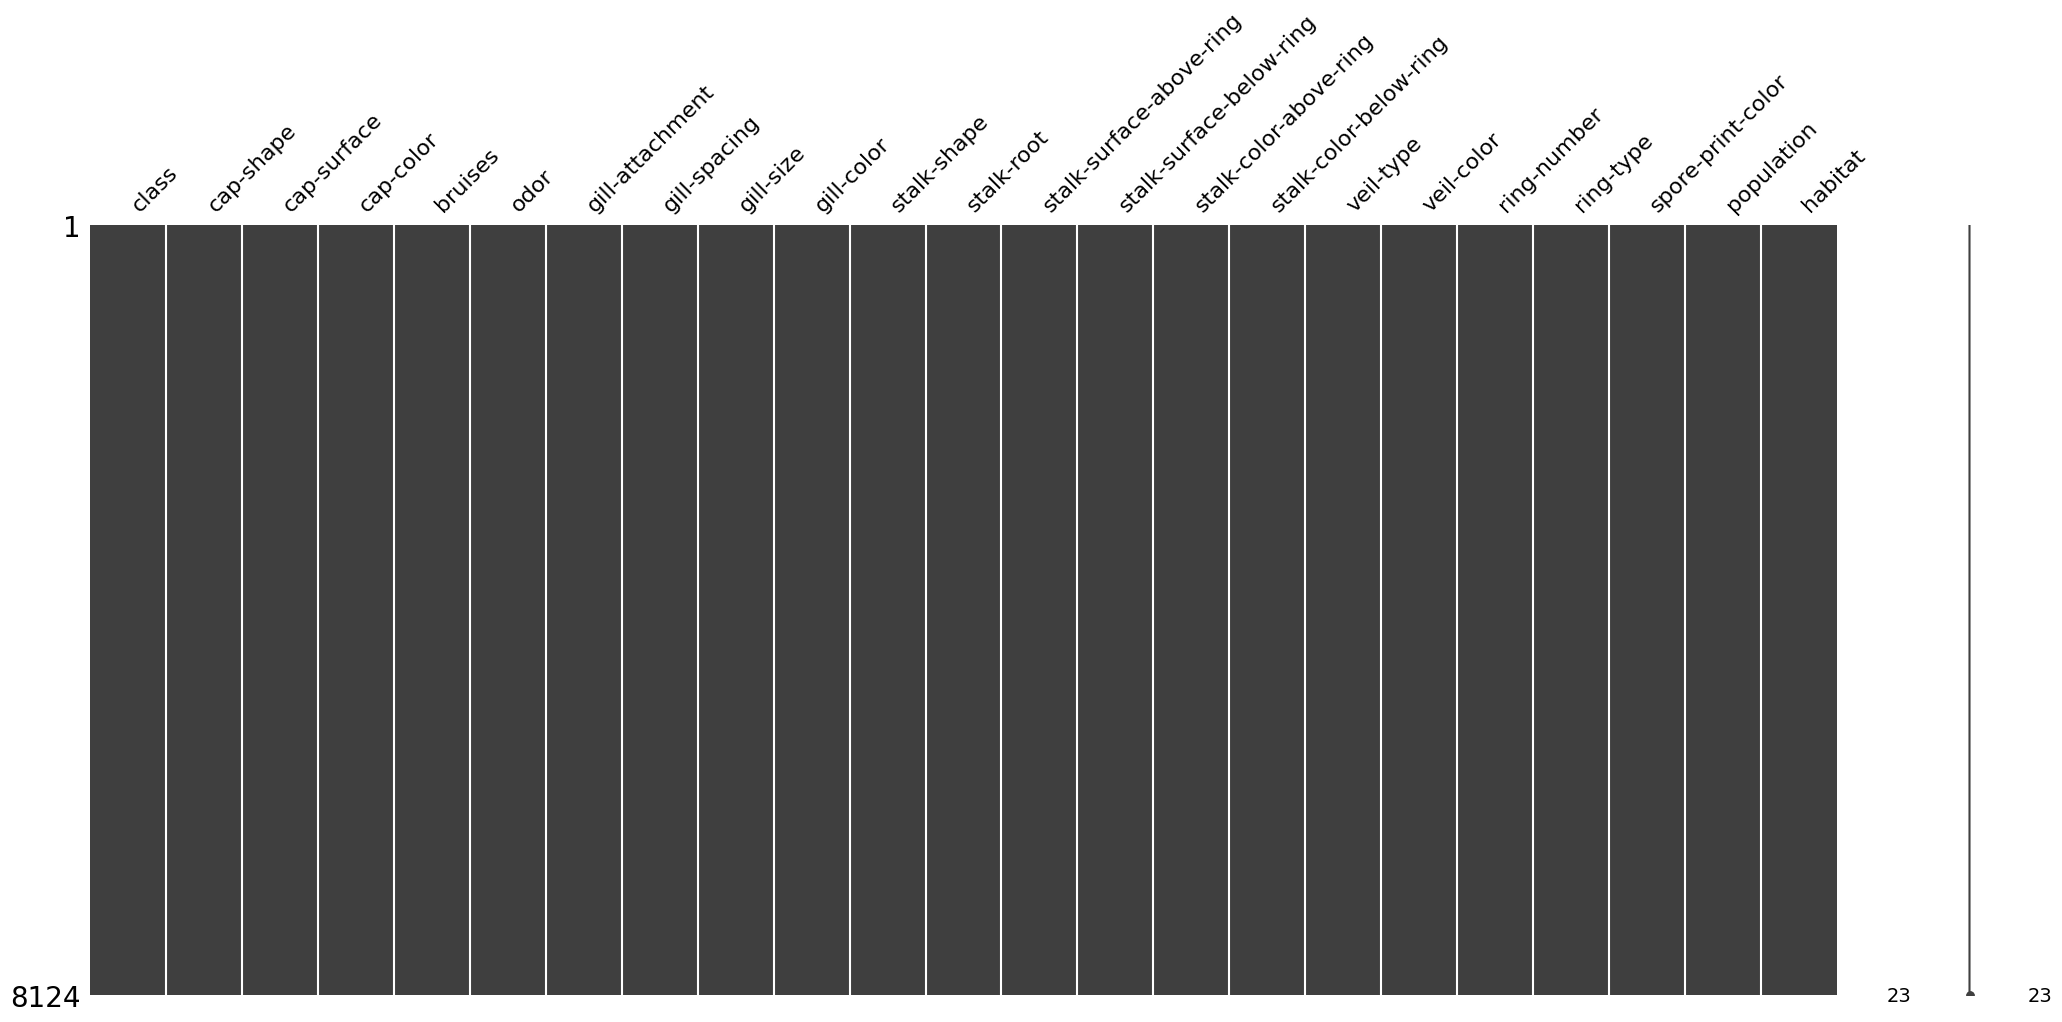

In [17]:
print('Missing values visualization')
print(('=')*29)
msno.matrix(df_copy)

We'll look for strange values in the columns, so we look for unique values.

In [18]:
#Dataframe with features and unique values.
print('Dataframe with features and unique values')
print(('=')*42)
feature = df_copy.columns
n_values = df_copy.nunique().values

dataframe_feature_nvalues = pd.DataFrame({
    "feature": feature,
    "n_values": n_values
})

display(dataframe_feature_nvalues)

Dataframe with features and unique values


,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


In the the context and with this dataframe we know the unique values in every column and their meaning, now we'll quantify how many are in each category.

In [19]:
print('Unique values of each column')
print(('=')*30)
for col in df_copy.columns:
    print(('_')*30 )
    print(df_copy[col].value_counts())


Unique values of each column
______________________________
class
e    4208
p    3916
Name: count, dtype: int64
______________________________
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
______________________________
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
______________________________
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
r      16
u      16
Name: count, dtype: int64
______________________________
bruises
f    4748
t    3376
Name: count, dtype: int64
______________________________
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
______________________________
gill-attachment
f    7914
a     210
Name: count, dtype: int64
______________________________
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
______________________________
gill-size
b    5612
n    2512
Name

The only strange thing here is the '?' variable in 'stalk-root' and that 'veil-type' has only one category so we'll impute the '?' values with KNN and will drop the 'stalk-root' column.

In [20]:
#Dropping 'veil-type' column.
print(f"Dataset BEFORE dropping 'veil-type' has {len(df_copy.columns)} columns")
print("✂ Dropping 'veil-type' column")
df_copy.drop('veil-type', axis=1, inplace=True) #axis=1 means columns, axis =0 means rows.
print(f"Dataset AFTER dropping 'veil-type' has {len(df_copy.columns)} columns")
print('✅ Veil-type column dropped')

Dataset BEFORE dropping 'veil-type' has 23 columns
✂ Dropping 'veil-type' column
Dataset AFTER dropping 'veil-type' has 22 columns
✅ Veil-type column dropped


In [21]:
'''#Imputing '?' category in 'stalk-root' column with KNN.
print('Steps to imputing "?" category in "stalk-root" column')
print(('=')*45) #It works with () or witout them.
print('\n')

print('1. Replacing "?" with NaN')
print('*'*26)
print(f'Unique values of "stalk-root" column BEFORE replacement: {df_copy["stalk-root"].unique()}')
df_copy['stalk-root'] = df_copy['stalk-root'].replace('?', np.nan)
print(f'Unique values of "stalk-root" column AFTER replacement: {df_copy["stalk-root"].unique()}')
print(' ✅ "?" category replaced with NaN')
print('\n')

nullsreplaced = msno.matrix(df_copy)
print('Missing values visualization after replacing "?" with NaN')
print(('=')*59)
print(nullsreplaced)'''


'#Imputing \'?\' category in \'stalk-root\' column with KNN.\nprint(\'Steps to imputing "?" category in "stalk-root" column\')\nprint((\'=\')*45) #It works with () or witout them.\nprint(\'\n\')\n\nprint(\'1. Replacing "?" with NaN\')\nprint(\'*\'*26)\nprint(f\'Unique values of "stalk-root" column BEFORE replacement: {df_copy["stalk-root"].unique()}\')\ndf_copy[\'stalk-root\'] = df_copy[\'stalk-root\'].replace(\'?\', np.nan)\nprint(f\'Unique values of "stalk-root" column AFTER replacement: {df_copy["stalk-root"].unique()}\')\nprint(\' ✅ "?" category replaced with NaN\')\nprint(\'\n\')\n\nnullsreplaced = msno.matrix(df_copy)\nprint(\'Missing values visualization after replacing "?" with NaN\')\nprint((\'=\')*59)\nprint(nullsreplaced)'

In [22]:
'''print('2. One Hot Encoding DataFrame (KNN needs numeric values)')
print('*'*57)
df_encoded = pd.get_dummies(df_copy, drop_first=False, dummy_na=True) #drop_first=False to keep all categories, dummy_na=True to create a column for NaN values.
print(f'Number of columns before OneHotEncoding: {len(df_copy.columns)}')
print(f'Number of columns after OneHotEncoding: {len(df_encoded.columns)}')
print(f'Number of columns added: {len(df_encoded.columns) - len(df_copy.columns)}')
print('✅ DataFrame one-hot encoded')
print('\n')'''



"print('2. One Hot Encoding DataFrame (KNN needs numeric values)')\nprint('*'*57)\ndf_encoded = pd.get_dummies(df_copy, drop_first=False, dummy_na=True) #drop_first=False to keep all categories, dummy_na=True to create a column for NaN values.\nprint(f'Number of columns before OneHotEncoding: {len(df_copy.columns)}')\nprint(f'Number of columns after OneHotEncoding: {len(df_encoded.columns)}')\nprint(f'Number of columns added: {len(df_encoded.columns) - len(df_copy.columns)}')\nprint('✅ DataFrame one-hot encoded')\nprint('\n')"

In [23]:
'''print('3. Apply KNN Imputer')
print('*'*21)
stalk_cols = [col for col in df_encoded.columns if col.startswith('stalk-root')] #columns that start with 'stalk-root'
print(f'Columns related to "stalk-root": {stalk_cols}')
print(f'NaN before KNN Imputation: {df_encoded[stalk_cols].isna().sum().sum()}')

imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df_encoded) 
df_imputed = pd.DataFrame(df_imputed, columns=df_encoded.columns)
print(f'NaN after KNN Imputation: {df_imputed[stalk_cols].isna().sum().sum()}')
print('✅ KNN Imputation applied')'''

'print(\'3. Apply KNN Imputer\')\nprint(\'*\'*21)\nstalk_cols = [col for col in df_encoded.columns if col.startswith(\'stalk-root\')] #columns that start with \'stalk-root\'\nprint(f\'Columns related to "stalk-root": {stalk_cols}\')\nprint(f\'NaN before KNN Imputation: {df_encoded[stalk_cols].isna().sum().sum()}\')\n\nimputer = KNNImputer(n_neighbors=5)\ndf_imputed = imputer.fit_transform(df_encoded) \ndf_imputed = pd.DataFrame(df_imputed, columns=df_encoded.columns)\nprint(f\'NaN after KNN Imputation: {df_imputed[stalk_cols].isna().sum().sum()}\')\nprint(\'✅ KNN Imputation applied\')'

In [24]:
'''df_copy['stalk-root'].value_counts(dropna=False)'''

"df_copy['stalk-root'].value_counts(dropna=False)"

In [25]:
'''print('Missing values visualized')
print(('=')*26)
msno.matrix(df_copy)'''

"print('Missing values visualized')\nprint(('=')*26)\nmsno.matrix(df_copy)"

### 4.3. DUPLICATES

In [26]:
print('Duplicated values')
print(('=')*18)
duplicates = df_copy.duplicated().sum()
if duplicates == 0:
    print(f'✓ There are no duplicated rows.')
else:
    print(f'✗ There are {duplicates} duplicated rows.')
    

Duplicated values
✓ There are no duplicated rows.


# 5. EXPLORATORY ANALYSIS

### 5.1. UNIVARIABLE ANALYSIS

Barplots are made to see the distribution of every category in each column. There are many where the frequency between categories is very different. In 'class', our variable to predict it is more or less equal each category (edible and poisonous).

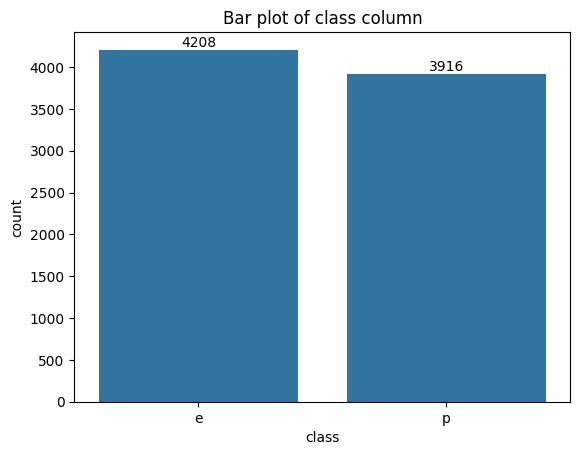

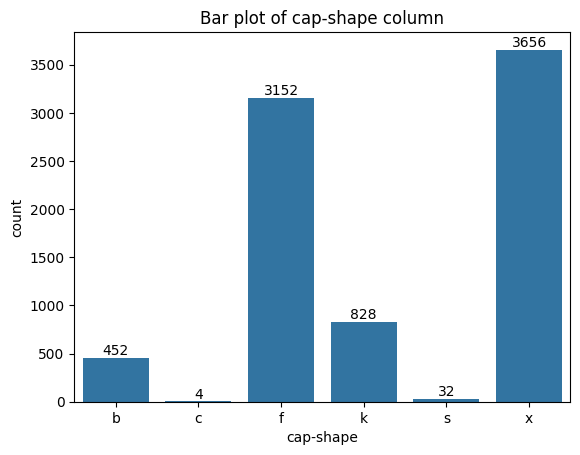

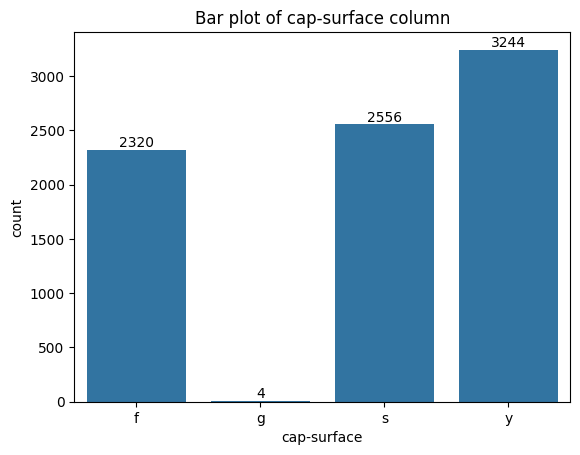

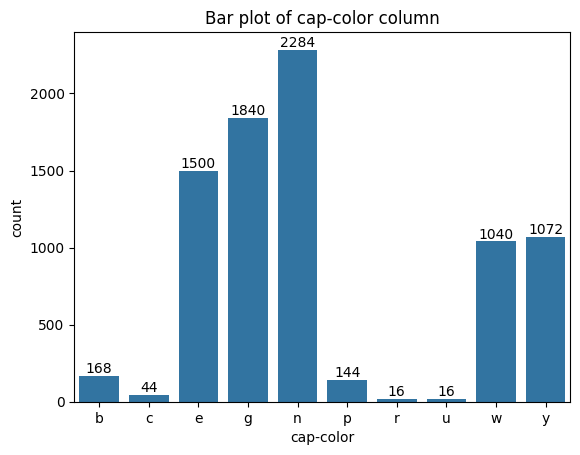

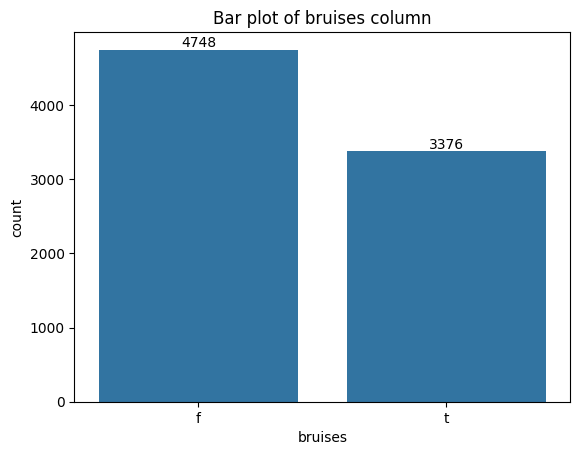

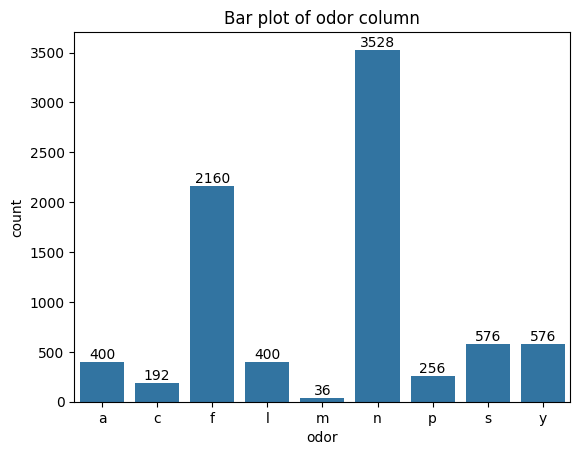

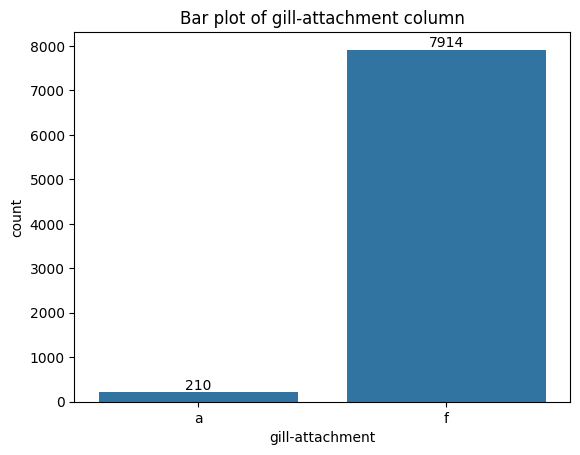

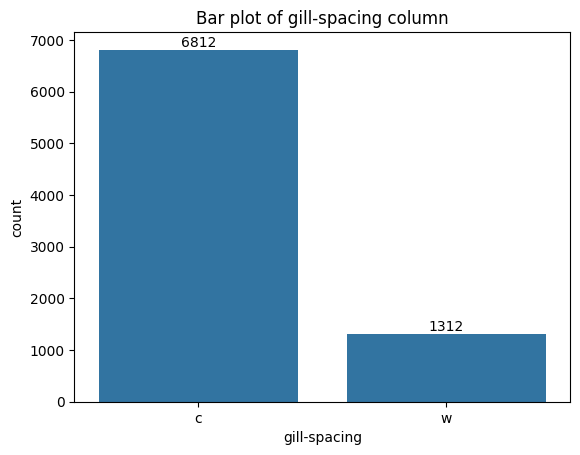

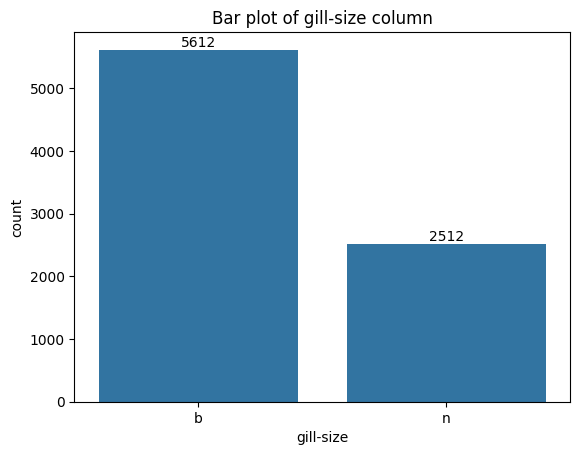

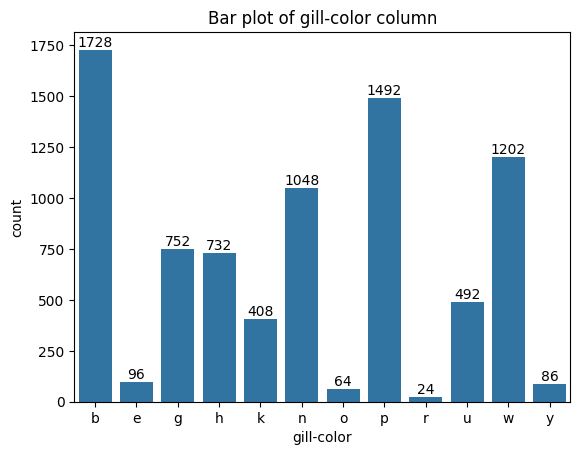

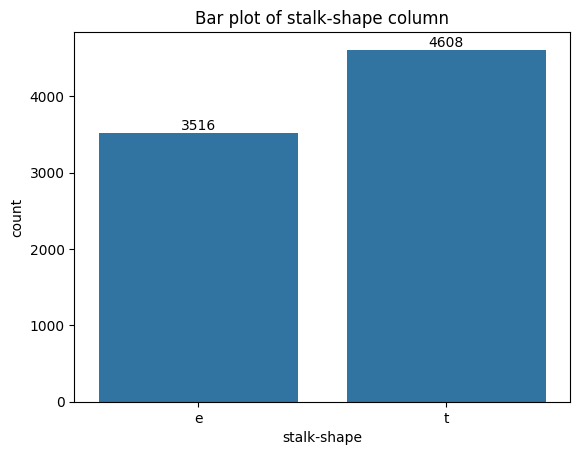

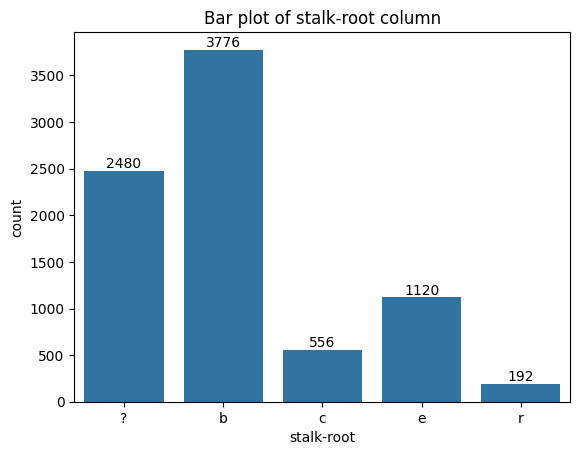

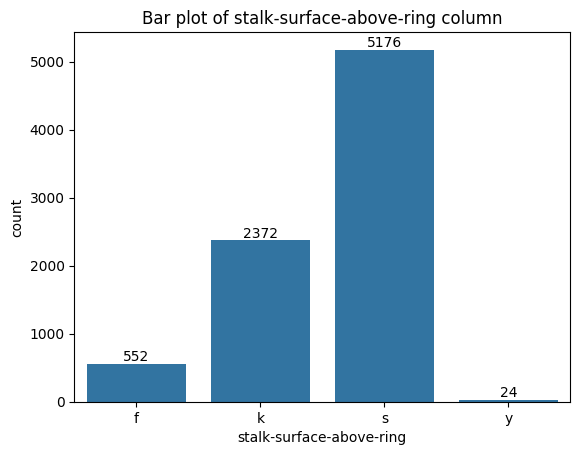

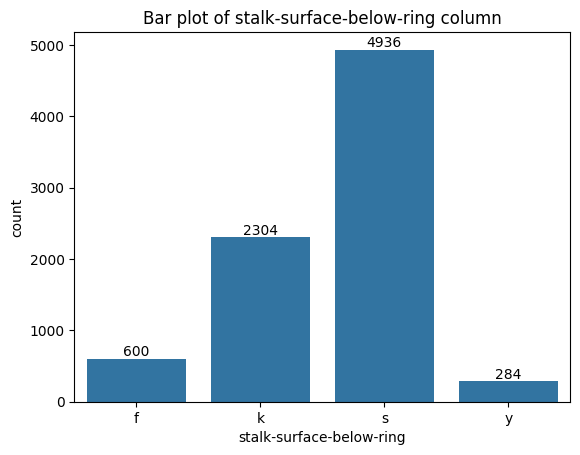

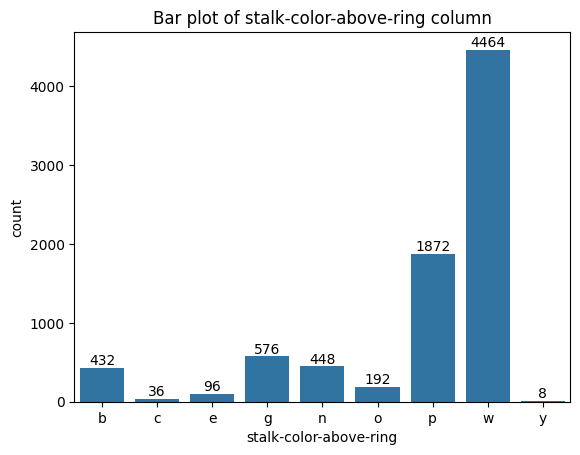

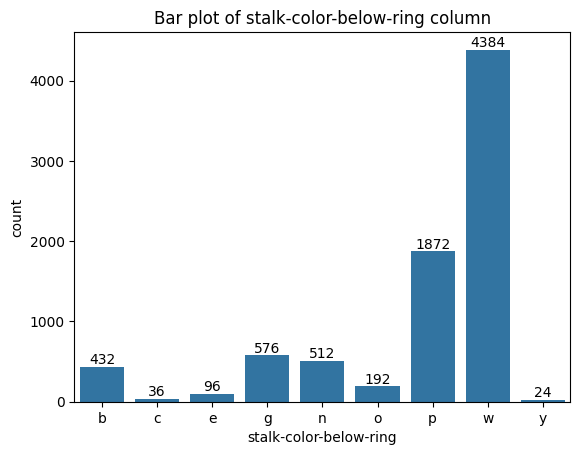

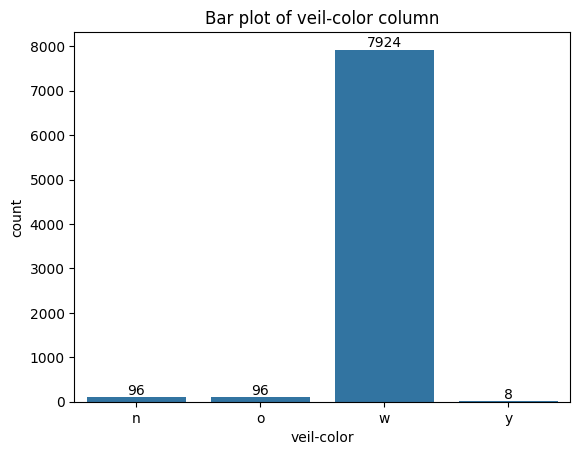

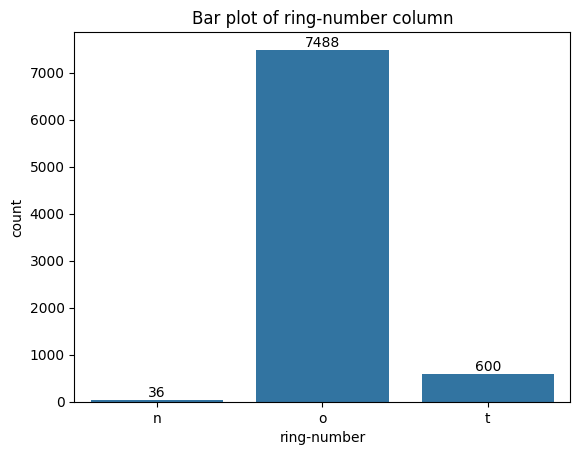

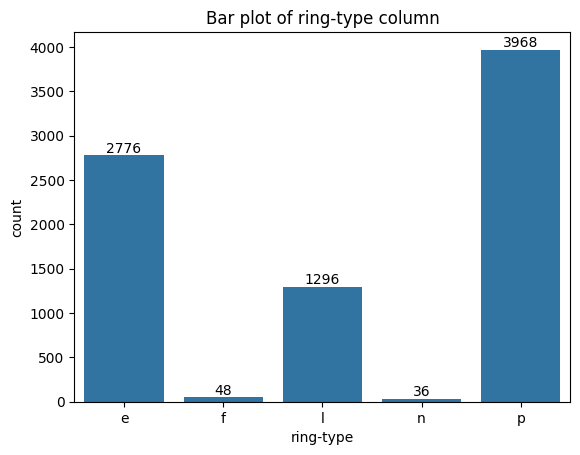

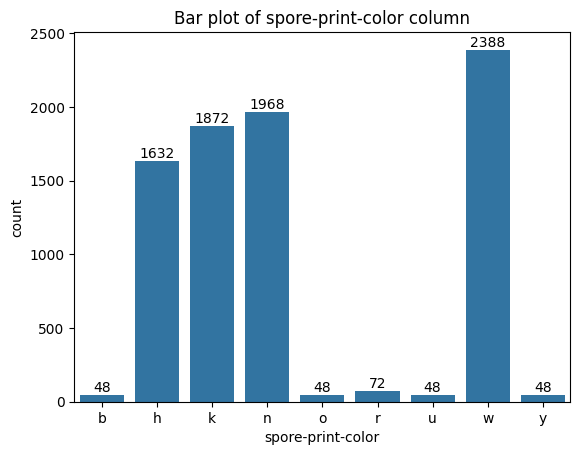

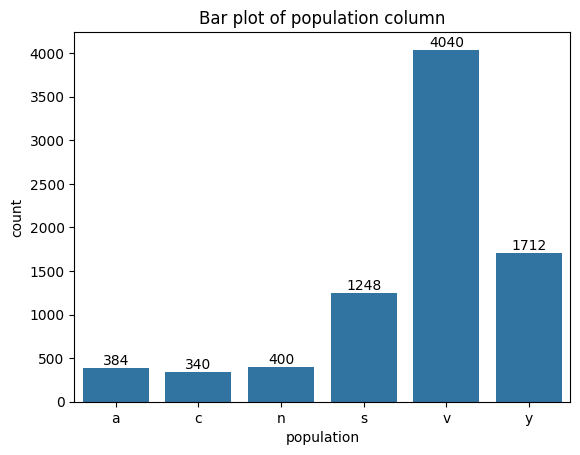

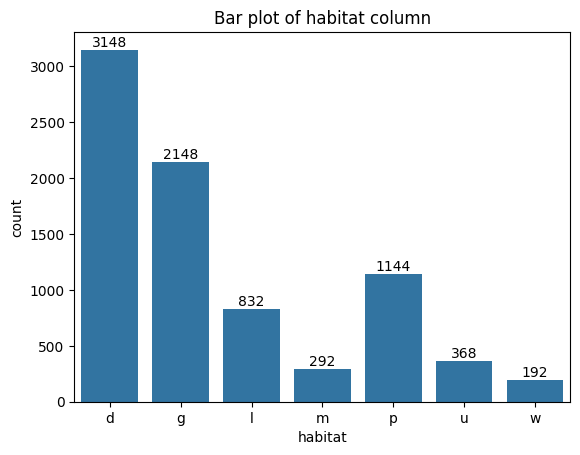

In [38]:
for col in df_copy.columns:
    barplot = sns.countplot(x=col, data=df_copy)
    plt.title(f'Bar plot of {col} column')
    for container in barplot.containers:
        barplot.bar_label(container, fontsize=10)

    plt.show()

### 5.2. BIVARIABLE ANALYSIS

Now, we'll compare 'class' with the other columns through a table of frequencies and grouped bar plots.

In [46]:
#Relationship between 'class' and other columns.
for col in df_copy.columns:
    if col != 'class':
        crosstab = pd.crosstab(df_copy['class'], df_copy[col])
        print(f'Crosstab between "class" and "{col}"')
        print(('=')*70)
        print(crosstab)
        print('\n')

Crosstab between "class" and "cap-shape"
cap-shape    b  c     f    k   s     x
class                                 
e          404  0  1596  228  32  1948
p           48  4  1556  600   0  1708


Crosstab between "class" and "cap-surface"
cap-surface     f  g     s     y
class                           
e            1560  0  1144  1504
p             760  4  1412  1740


Crosstab between "class" and "cap-color"
cap-color    b   c    e     g     n   p   r   u    w    y
class                                                    
e           48  32  624  1032  1264  56  16  16  720  400
p          120  12  876   808  1020  88   0   0  320  672


Crosstab between "class" and "bruises"
bruises     f     t
class              
e        1456  2752
p        3292   624


Crosstab between "class" and "odor"
odor     a    c     f    l   m     n    p    s    y
class                                              
e      400    0     0  400   0  3408    0    0    0
p        0  192  2160    0  36   120

We can see sometimes that 'edible' or 'poisonous' is zero in one or more category in a column. It means that this category could help a lot to predict if the mushroom is edible or poisonous. Because if the category is found in edible and poisonous it can't help to predict the 'class'.

For example, in 'ring-type', if the mushroom has ring-type 'f' (flaring) it means the mushroom is edible. If it has ring-type 'l' (large) or 'n' (none) it means the mushroom is poisonous. Meanwhile if the ring-type is 'e' (evanescent) or 'p' (pendant) it means the mushroom could be edible or poisonous.

<Figure size 800x500 with 0 Axes>

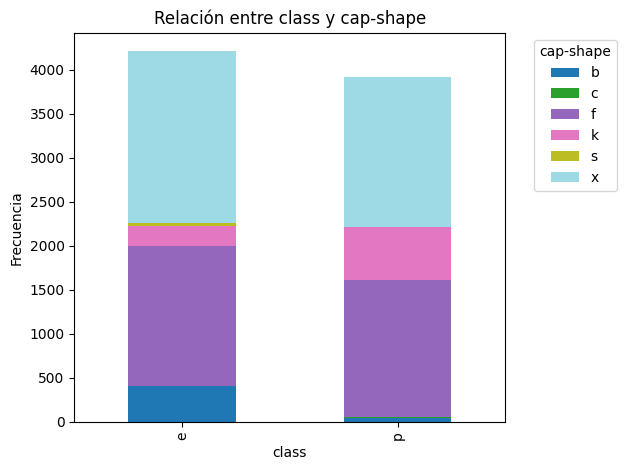

<Figure size 800x500 with 0 Axes>

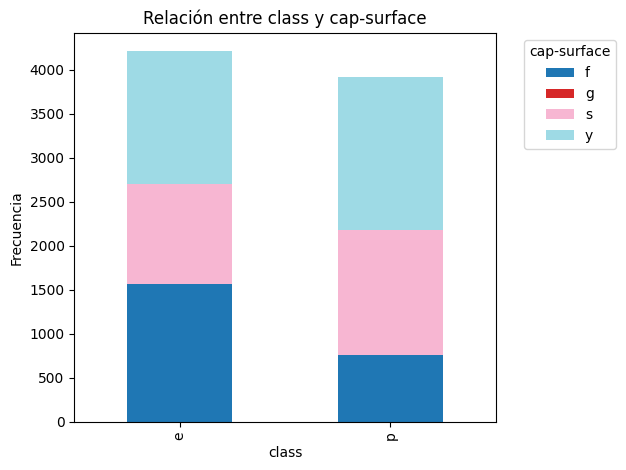

<Figure size 800x500 with 0 Axes>

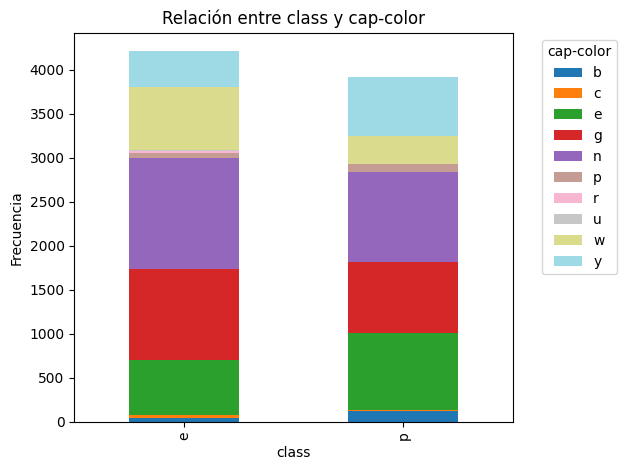

<Figure size 800x500 with 0 Axes>

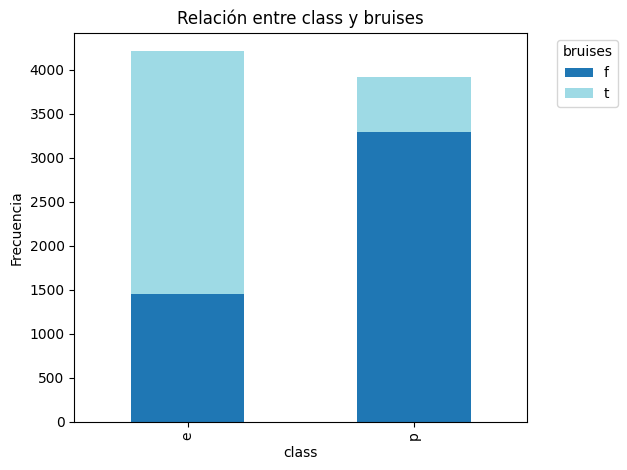

<Figure size 800x500 with 0 Axes>

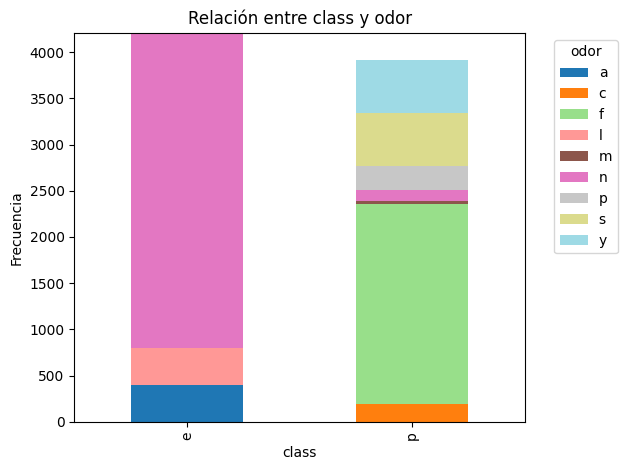

<Figure size 800x500 with 0 Axes>

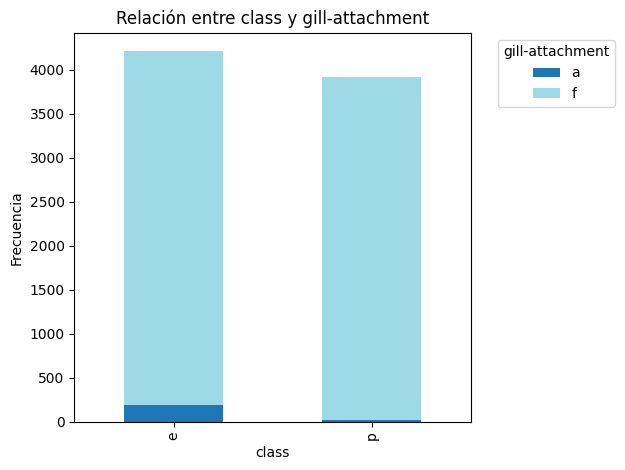

<Figure size 800x500 with 0 Axes>

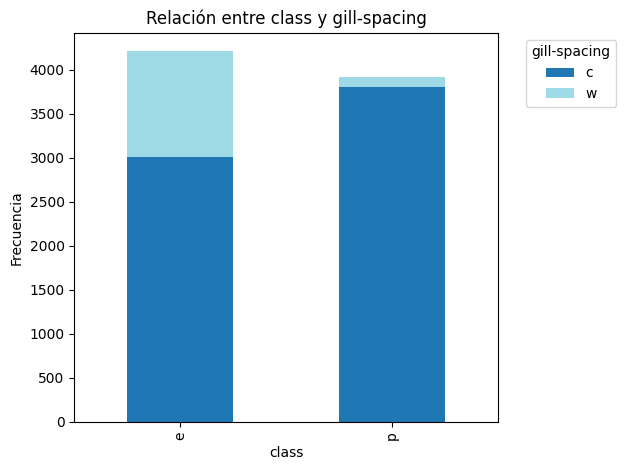

<Figure size 800x500 with 0 Axes>

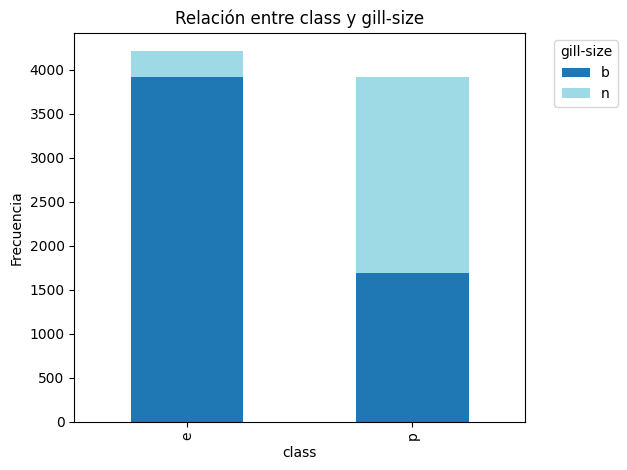

<Figure size 800x500 with 0 Axes>

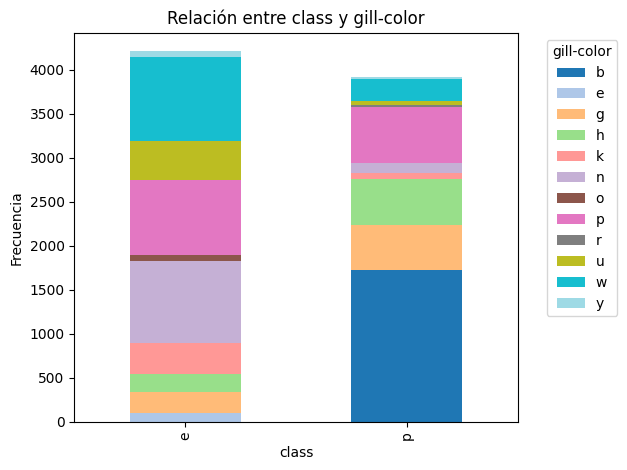

<Figure size 800x500 with 0 Axes>

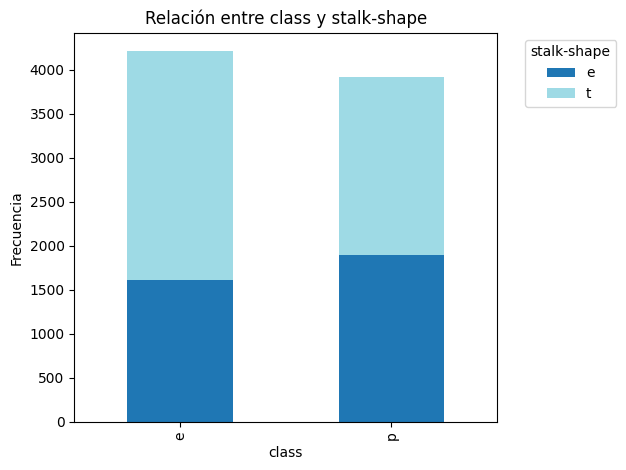

<Figure size 800x500 with 0 Axes>

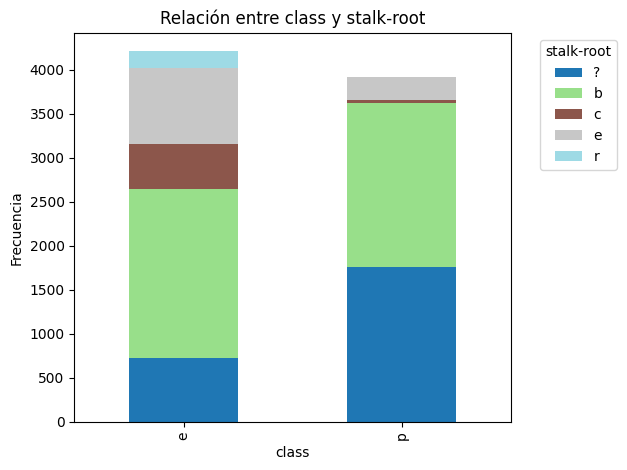

<Figure size 800x500 with 0 Axes>

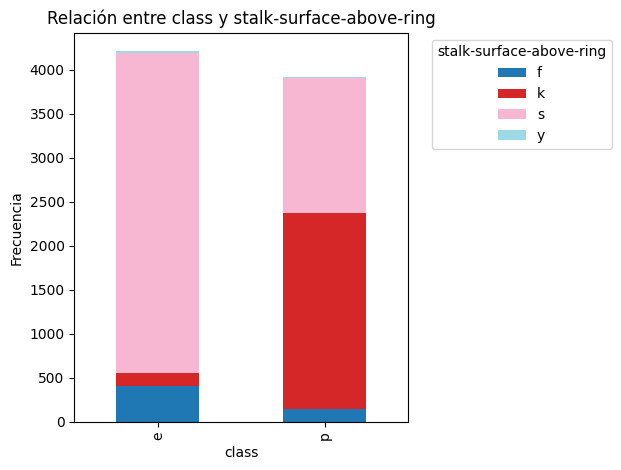

<Figure size 800x500 with 0 Axes>

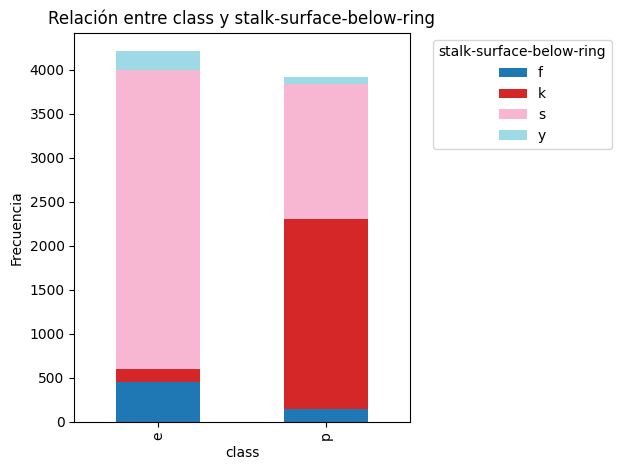

<Figure size 800x500 with 0 Axes>

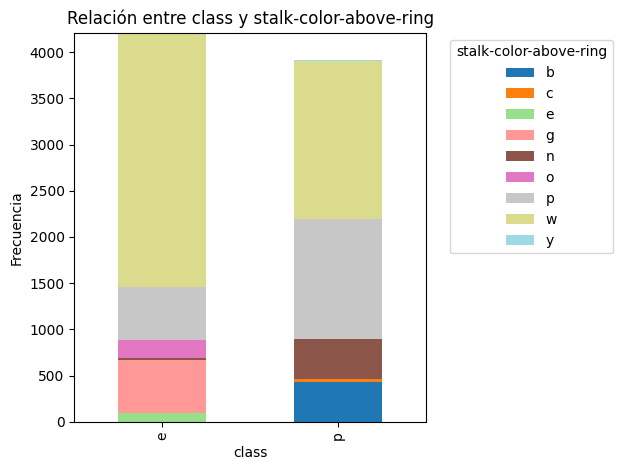

<Figure size 800x500 with 0 Axes>

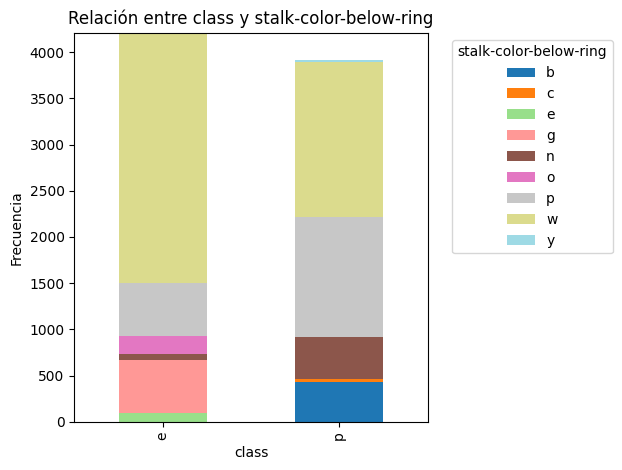

<Figure size 800x500 with 0 Axes>

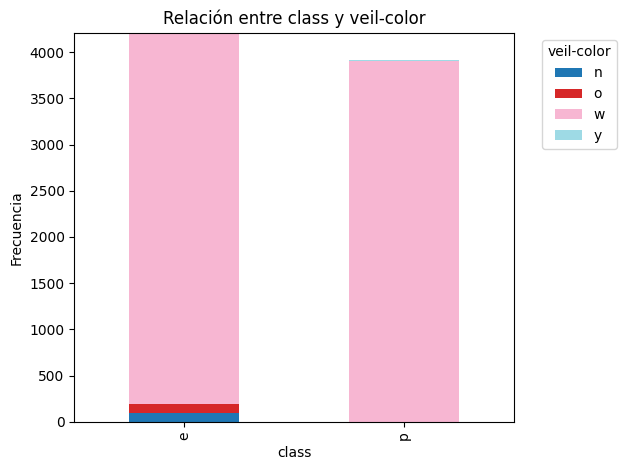

<Figure size 800x500 with 0 Axes>

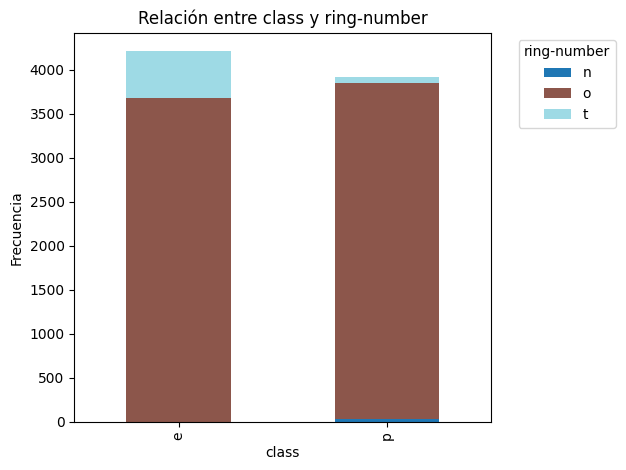

<Figure size 800x500 with 0 Axes>

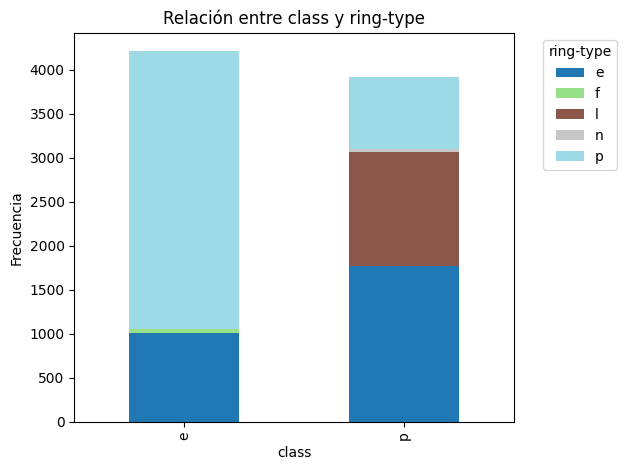

<Figure size 800x500 with 0 Axes>

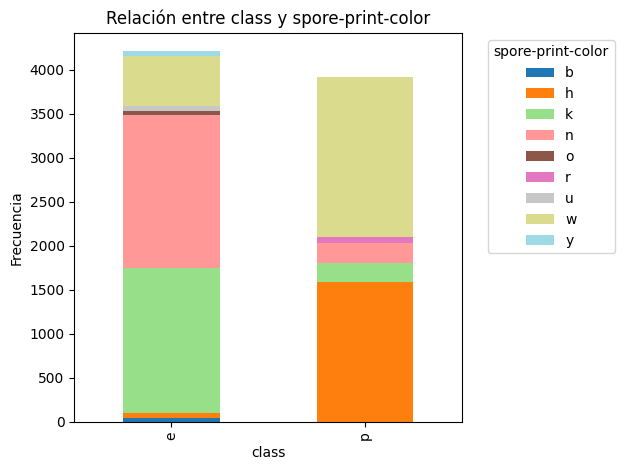

<Figure size 800x500 with 0 Axes>

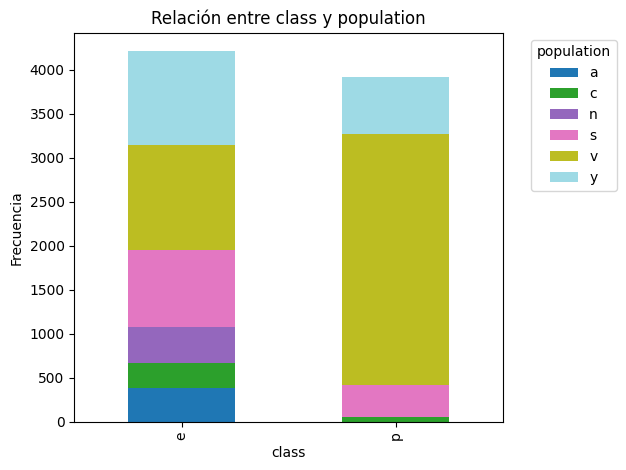

<Figure size 800x500 with 0 Axes>

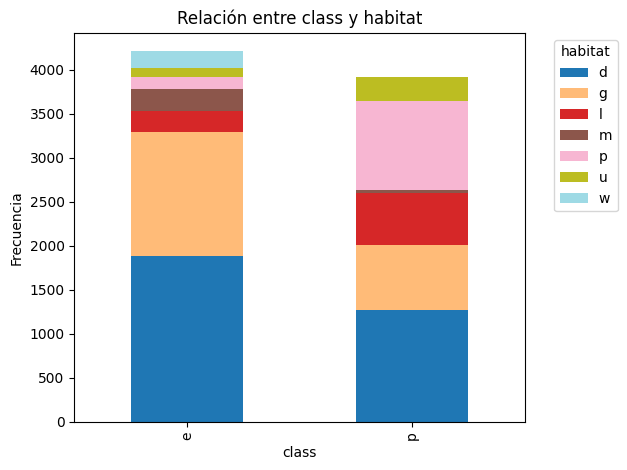

In [44]:
for col in df_copy.columns:
    if col != 'class':
        crosstab = pd.crosstab(df_copy['class'], df_copy[col])
        plt.figure(figsize=(8,5))
        crosstab.plot(kind='bar', stacked=True, colormap='tab20')
        plt.title(f'Relación entre class y {col}')
        plt.xlabel('class')
        plt.ylabel('Frecuencia')
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()


With those graphics we can know fast if there is any category that only exits in edible or poisonous. For example, in 'ring-number' we can know this column won't be helpful to predict because the distribution between edible and poisonous is very similar. And with 'odor' if it is 'n' (none) it means it is very probably that the mushroom is edible, although there is a probability that isn't.

### 5.3. MULTIVARIABLE ANALYSIS

With numeric variables we use matrix correlation (Pearson), but in this case we use Cramérs' V matrix because the variables are categorical (Chi squared).

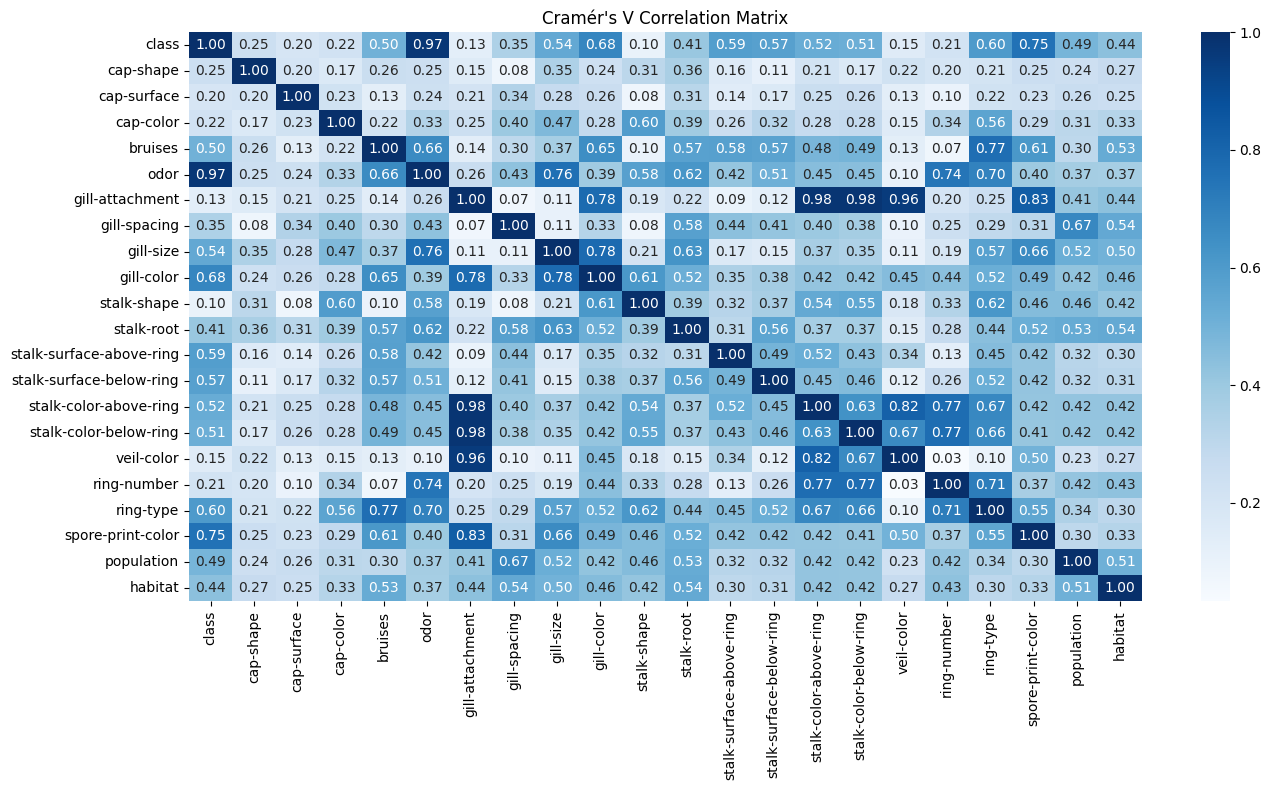

In [51]:
#Cramer's V function
def cramers_v(x, y): #correlation between two columns
    crosstab = pd.crosstab(x, y) #frequency table between two columns (see bivariable analysis)
    chi2 = chi2_contingency(crosstab)[0] #calculate chi-squared
    n = len(x) #rows
    k = min(crosstab.shape) - 1 #number of min categories in the two columns minus one
    return np.sqrt(chi2 / (n * k)) #Cramer's V formula: sqrt(chi2 / (n * k)) (result between 0 and 1))

#Cramer's V matrix
cols = df_copy.columns
matrix = pd.DataFrame(index=cols, columns=cols, dtype=float) #empty table

for col1 in cols: #it iterates through all combinations
    for col2 in cols:
        matrix.loc[col1, col2] = cramers_v(df_copy[col1], df_copy[col2]) #values for the empty table 

plt.figure(figsize=(14, 8))
sns.heatmap(matrix.astype(float), annot=True, fmt='.2f', cmap='Blues') #annot=True to show values, fmt='.2f' two decimals
plt.title("Cramér's V Correlation Matrix")
plt.tight_layout()
plt.show()

This matrix goes from 0 (no correlated) to 1 (correlated).

Here we can see easier the things we started to see in the bivariable analysis. The easier example to understand is 'odor'. It has many categories and most of them has a zero in 'edible' or in 'poisonous'. It means this column is highly correlated to class as wee see in the matrix. 

That first column is the most interesting to the prediction, but there are other correlations as 'stalk-color-above-ring' and 'gill-attachment'.

### 5.4. EDA CONCLUSION

'Class' has some correlated variables like 'odor' and 'spore-print-color' that could be helpful to predict 'class'. I also has other like 'cap-shape', 'cap-surface' and 'cap-color' that wuldn't be helpful. 

#### Tratar aquellos valores que entendamos que sean nulos


In [30]:
# Imputaciones. Podéis quitar esos puntos (fila entera), imputar con la moda o dejar ese valor como una posibilidad más.

#### Mirad cuántos valores hay en cada feature, ¿Todas las features aportan información? Si alguna no aporta información, eliminadla

In [31]:
# Dejar por el camino si procede.

#### Separar entre variables predictoras y variables a predecir

In [32]:
# La variable que trata de predecir este conjunto de datos es 'poisonous'.
y =
X =

SyntaxError: invalid syntax (3365642098.py, line 2)

#### Codificar correctamente las variables categóricas a numéricas

In [ ]:
# One Hot Encoder (una linea).

#### Train test split

In [ ]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto nada (no tenemos graficas) así que vamos a hacer algunas. Tenemos el problema de que son muchas variables, **PCA al rescate**: le pedimos que nos de dos dimensiones y las pintamos, sabemos que serán **aquellas que retengan más información**.

In [ ]:
pca =       # metodo de sklearn
pca.fit(X_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento

Parece que está bastante separadito, parece que a ojo mucho se puede ver :)

Igualmente, vamos a entrenar un clasificador a ver qué tal lo hace antes de editar más

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definir el clasificador y el número de estimadores
# 2. Entrenar en train
# 3. Calcular la precisión sobre test

Es un conjunto sencillo y Random Forest es muy bueno en su trabajo, Igualmente, vamos a ver qué tamaño tenemos de dataset:


In [ ]:
X_train.shape

¿Muchas features no? Vamos a reducir las usando PCA.

In [ ]:
n_features = # definir un rango de valores a probar
scores = []

for n in n_features:

    # Hacer PCA sobre X_train
    # 1. Definir PCA
    # 2. Aprender PCA sobre X_train

    # Entrenar Random Forest
    # 1. Definir el RF
    # 2. Entrenar clasificador

    # Guardar el score


sns.lineplot(x=n_features, y=scores)


Vale, estamos viendo que a partir de unas 10 features ya tenemos el score que queríamos y además hemos reducido las variables a un 10% de las que teníamos, incluso menos que las variables originales.

## Clustering

Viendo que el conjunto de datos es sencillito, podemos intentar hacer algo de clustering a ver qué información podemos obtener.

El primer paso va a ser importar la función de Kmeans de sklearn, y a partir de ahi, vamos a buscar el valor óptimo de clusters. Como hemos visto anteriormente, este valor lo obtenemos, por ejemplo, del codo de la gráfica que representa el total de las distancias de los puntos a los centros de los clusters asociados. Os dejo la página de la documentación de sklearn para que lo busquéis:

[K-Means on sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

Con esto solo hay que ahora generar los modelos de kmeans, evaluar y pintar la gráfica para los valores de ``k`` que establezcais.




In [ ]:
from sklearn.cluster import KMeans

scores = []
k_values = # definir un rango
for a in k_values:

    # Definir Kmeans y ajustar
    # Guardar la predicción

sns.lineplot(x=k_values, y=scores)

Con el valor que hayáis obtenido de la gráfica, podéis obtener una buena aproximación de Kmeans y con ello podemos pasar a explorar cómo de bien han separado la información los distintos clusters. Para ello, se va a hacer un ``catplot``, seaborn os lo hará solito. Con esto lo que se pretende ver es la distribución de la varaible a predecir en función del cluster que haya determinado Kmeans.

In [ ]:
# Aprender Kmeans con el valor de K obtenido.

kmeans = # Definir y entrenar Kmeans.

# Preparar el catplot.


# Pintar.
ax = sns.catplot(col=, x=, data=, kind='count',col_wrap=4)

Vamos a ver qué tal queda esto pintado. Para ello, repetimos el scatterplot de antes pero usando como color el cluster asignado por kmeans.

In [ ]:
# Entrenar PCA para representar.

# Usar un color por cada cluster.


¿Es bastante parecido no? No es tan bueno como el Random Forest, pero ha conseguido identificar bastante bien los distintos puntos del dataset sin utilizar las etiquetas. De hecho, el diagrama de factor que hemos visto antes muestra que solo un par de clusters son imprecisos. Si no hubieramos tenido etiquetas esta aproximacion nos hubiera ayudado mucho a clasificar los distintos tipos de hongos.